## De inicio eu pensei em seguir com esses passos 

### tratar os dados $\longrightarrow$ modelo $\longrightarrow$ o que o modelo quer dizer pra mim com os dados $\longrightarrow$ selecionar os sensores mais importantes $\longrightarrow$ acho que construir serie temportal para os sensores mais relevantes (importantes).



In [141]:
import pandas as pd 
import glob
import seaborn as sns
import matplotlib.pyplot as plt

In [142]:
# ============================================================================
# CARREGAMENTO DOS DADOS                                                     
#                                                                            
# A ideia de início foi pegar cada csv na qual cada csv                      
# vai ser um um unico data frame, uma coluna unido pelo timestamp            
#                                                                            
# ficaria algo como                                                          
#                                                                                                                                                    |
# |--------------------------------------------------------------------------
# |     timestamp     |  target_iALL_PS  |  TAG_iALL_PS_00   |.......        
# |2018-04-01 00:00:00|      NORMAL      |    4.54875372     |.......        
# |        .                   .                   .             .           
# |        .                   .                   .             .           
# |        .                   .                   .             .           
# |        .                   .                   .             .           
# |__________________________________________________________________________
#                                                                            
# ===========================================================================

caminho_csvs = "/home/thierry-martins-ribeiro/Documentos/IC/ps/new_data"

sensores = glob.glob(caminho_csvs + "/TAG_iALL_PS_*.csv") 
sensor_taget = pd.read_csv(caminho_csvs + '/target_iALL_PS.csv')

dado_frame = sensor_taget.copy()
for i in sensores:
    sensor = pd.read_csv(i)
    dado_frame = pd.merge(dado_frame, sensor, on='timestamp', how='left')



sensor_coluna = [coluna for coluna in dado_frame.columns if coluna.startswith('TAG')] 
 
print("dimensão df:")
print(dado_frame.shape)

print("tipo:")
print(dado_frame.dtypes) #object pq é uma combinação de ano/mes/dia (data) 

dimensão df:
(220320, 54)
tipo:
timestamp          object
target_iALL_PS     object
TAG_iALL_PS_49    float64
TAG_iALL_PS_39    float64
TAG_iALL_PS_17    float64
TAG_iALL_PS_05    float64
TAG_iALL_PS_14    float64
TAG_iALL_PS_50    float64
TAG_iALL_PS_23    float64
TAG_iALL_PS_11    float64
TAG_iALL_PS_30    float64
TAG_iALL_PS_09    float64
TAG_iALL_PS_18    float64
TAG_iALL_PS_36    float64
TAG_iALL_PS_22    float64
TAG_iALL_PS_07    float64
TAG_iALL_PS_19    float64
TAG_iALL_PS_42    float64
TAG_iALL_PS_15    float64
TAG_iALL_PS_08    float64
TAG_iALL_PS_06    float64
TAG_iALL_PS_20    float64
TAG_iALL_PS_24    float64
TAG_iALL_PS_40    float64
TAG_iALL_PS_44    float64
TAG_iALL_PS_26    float64
TAG_iALL_PS_03    float64
TAG_iALL_PS_13    float64
TAG_iALL_PS_33    float64
TAG_iALL_PS_47    float64
TAG_iALL_PS_43    float64
TAG_iALL_PS_00    float64
TAG_iALL_PS_21    float64
TAG_iALL_PS_34    float64
TAG_iALL_PS_32    float64
TAG_iALL_PS_28    float64
TAG_iALL_PS_51    float64
TAG_iA

In [143]:
print(sensores)

['/home/thierry-martins-ribeiro/Documentos/IC/ps/new_data/TAG_iALL_PS_49.csv', '/home/thierry-martins-ribeiro/Documentos/IC/ps/new_data/TAG_iALL_PS_39.csv', '/home/thierry-martins-ribeiro/Documentos/IC/ps/new_data/TAG_iALL_PS_17.csv', '/home/thierry-martins-ribeiro/Documentos/IC/ps/new_data/TAG_iALL_PS_05.csv', '/home/thierry-martins-ribeiro/Documentos/IC/ps/new_data/TAG_iALL_PS_14.csv', '/home/thierry-martins-ribeiro/Documentos/IC/ps/new_data/TAG_iALL_PS_50.csv', '/home/thierry-martins-ribeiro/Documentos/IC/ps/new_data/TAG_iALL_PS_23.csv', '/home/thierry-martins-ribeiro/Documentos/IC/ps/new_data/TAG_iALL_PS_11.csv', '/home/thierry-martins-ribeiro/Documentos/IC/ps/new_data/TAG_iALL_PS_30.csv', '/home/thierry-martins-ribeiro/Documentos/IC/ps/new_data/TAG_iALL_PS_09.csv', '/home/thierry-martins-ribeiro/Documentos/IC/ps/new_data/TAG_iALL_PS_18.csv', '/home/thierry-martins-ribeiro/Documentos/IC/ps/new_data/TAG_iALL_PS_36.csv', '/home/thierry-martins-ribeiro/Documentos/IC/ps/new_data/TAG_iA

In [144]:
print(dado_frame.head())

             timestamp target_iALL_PS  TAG_iALL_PS_49  TAG_iALL_PS_39  \
0  2018-04-01 00:00:00         NORMAL      124.735196      120.531554   
1  2018-04-01 00:01:00         NORMAL      158.822485       94.319273   
2  2018-04-01 00:02:00         NORMAL       88.772027       40.182165   
3  2018-04-01 00:03:00         NORMAL       53.387484       64.405477   
4  2018-04-01 00:04:00         NORMAL      168.746952       31.432756   

   TAG_iALL_PS_17  TAG_iALL_PS_05  TAG_iALL_PS_14  TAG_iALL_PS_50  \
0      223.192894       97.284889      813.860487      426.651658   
1     1225.833795      202.583688      630.768876      375.316113   
2       42.455318      147.098428      985.782418      444.809188   
3      525.719895      307.722320      846.300679      414.052496   
4      950.064772       -7.684779      794.012881      431.548430   

   TAG_iALL_PS_23  TAG_iALL_PS_11  ...  TAG_iALL_PS_16  TAG_iALL_PS_02  \
0     2220.187843      123.338718  ...     1153.330628       58.698896  

In [145]:
# ============================================================================
# Verifica como os dados estão estruturados                                  
#                                                                            
# Antes de partir para o tratamento dos dados eu dei uma olhada nos csvs     
# e percebi muitos dados NaN ou valores ausentes esses valores poderia dar   
# dificultar o meu modelo de prever as falhas                                
# Uma outra observação que eu tive foi que nos dado NaN foi o momento em que 
# o sensor falhou                                                              
# com isso eu verifiquei a quantidade de NaN de cada coluna.                  
# ============================================================================ 

print("Quantidade de NaN:")
print(dado_frame.isnull().sum())

Quantidade de NaN:
timestamp              0
target_iALL_PS         0
TAG_iALL_PS_49        27
TAG_iALL_PS_39        27
TAG_iALL_PS_17        46
TAG_iALL_PS_05        19
TAG_iALL_PS_14        21
TAG_iALL_PS_50     77017
TAG_iALL_PS_23        16
TAG_iALL_PS_11        19
TAG_iALL_PS_30       261
TAG_iALL_PS_09      4595
TAG_iALL_PS_18        46
TAG_iALL_PS_36        16
TAG_iALL_PS_22        41
TAG_iALL_PS_07      5451
TAG_iALL_PS_19        16
TAG_iALL_PS_42        27
TAG_iALL_PS_15    220320
TAG_iALL_PS_08      5107
TAG_iALL_PS_06      4798
TAG_iALL_PS_20        16
TAG_iALL_PS_24        16
TAG_iALL_PS_40        27
TAG_iALL_PS_44        27
TAG_iALL_PS_26        20
TAG_iALL_PS_03        19
TAG_iALL_PS_13        19
TAG_iALL_PS_33        16
TAG_iALL_PS_47        27
TAG_iALL_PS_43        27
TAG_iALL_PS_00     10208
TAG_iALL_PS_21        16
TAG_iALL_PS_34        16
TAG_iALL_PS_32        68
TAG_iALL_PS_28        16
TAG_iALL_PS_51     15383
TAG_iALL_PS_46        27
TAG_iALL_PS_35        16
TAG_iA

In [146]:
print(dado_frame.count())
#então que dizer que o dataset 15 nao tem nada. O sensor não funciona..... 

timestamp         220320
target_iALL_PS    220320
TAG_iALL_PS_49    220293
TAG_iALL_PS_39    220293
TAG_iALL_PS_17    220274
TAG_iALL_PS_05    220301
TAG_iALL_PS_14    220299
TAG_iALL_PS_50    143303
TAG_iALL_PS_23    220304
TAG_iALL_PS_11    220301
TAG_iALL_PS_30    220059
TAG_iALL_PS_09    215725
TAG_iALL_PS_18    220274
TAG_iALL_PS_36    220304
TAG_iALL_PS_22    220279
TAG_iALL_PS_07    214869
TAG_iALL_PS_19    220304
TAG_iALL_PS_42    220293
TAG_iALL_PS_15         0
TAG_iALL_PS_08    215213
TAG_iALL_PS_06    215522
TAG_iALL_PS_20    220304
TAG_iALL_PS_24    220304
TAG_iALL_PS_40    220293
TAG_iALL_PS_44    220293
TAG_iALL_PS_26    220300
TAG_iALL_PS_03    220301
TAG_iALL_PS_13    220301
TAG_iALL_PS_33    220304
TAG_iALL_PS_47    220293
TAG_iALL_PS_43    220293
TAG_iALL_PS_00    210112
TAG_iALL_PS_21    220304
TAG_iALL_PS_34    220304
TAG_iALL_PS_32    220252
TAG_iALL_PS_28    220304
TAG_iALL_PS_51    204937
TAG_iALL_PS_46    220293
TAG_iALL_PS_35    220304
TAG_iALL_PS_41    220293


In [147]:
print(dado_frame.shape)

(220320, 54)


In [148]:
# ============================================================================
# Só uma verificação aleatória para ver quando o sensor começou a funcionar  
# e quando parou. A ideia e ver se cruza com o intervalo                     
#============================================================================ 


csv_escolha = 'TAG_iALL_PS_00'
nan_ds0 = dado_frame[csv_escolha].isna()
nanmax= dado_frame[nan_ds0]['timestamp'].max()
nanmin = dado_frame[nan_ds0]['timestamp'].min()
nanmaxtil = dado_frame[~nan_ds0]['timestamp'].max()
nanmintil = dado_frame[~nan_ds0]['timestamp'].min()
print(nanmax)
print(nanmin)
print(nanmaxtil)
print(nanmintil)

2018-08-31 18:50:00
2018-04-12 22:00:00
2018-08-31 23:59:00
2018-04-01 00:00:00


In [149]:
print(dado_frame.shape)

(220320, 54)


In [150]:
# ============================================================================
# A ideia de verificar os dados faltantes do dataset foi muito importante    
# percebi que o dataset 15 tinha somente dados faltante, então para nao      
# atrapalhar na previsao, decidi tira-lo do meu data frame                   
# ============================================================================        
                                                                   
dado_frame = dado_frame.drop(columns=['TAG_iALL_PS_15'])

print(dado_frame.shape[0])
print(dado_frame.dropna().shape[0])
print(dado_frame.shape[0] - dado_frame.dropna().shape[0])

220320
119103
101217


In [151]:
print(dado_frame.shape)

(220320, 53)


In [152]:
# ============================================================================
# Nessas duas analise de dado dado_frame.isnull().sum()) e dado_frame.count()
# consegui perceber que alguns datasets tem muitos dados faltantes, então 
# decide pegar uma amostra 1 a cada 5 min para diminuir a quantidade de dados
# não e interessante pegar todos os dados faltantes, porque isso pode atrapalhar
# o modelo, então decidi pegar uma amstra 1 a cada 5 min 
#============================================================================ 

dado_frame = dado_frame.iloc[::5].reset_index(drop=True)
print(dado_frame.shape[0]) #-> qunatidade das linhas das amostras 
print(dado_frame.dropna().shape[0]) #->quantidade das linhas das amostras sem os nan

44064
23817


In [153]:
print(dado_frame.shape)

(44064, 53)


In [154]:
print(dado_frame['target_iALL_PS'].value_counts())

target_iALL_PS
NORMAL     41164
ANORMAL     2900
Name: count, dtype: int64


In [155]:
print(dado_frame['target_iALL_PS'].value_counts(normalize=True)*100)

target_iALL_PS
NORMAL     93.418664
ANORMAL     6.581336
Name: proportion, dtype: float64


In [156]:
print(dado_frame.shape)

(44064, 53)


In [157]:
print(dado_frame)

                 timestamp target_iALL_PS  TAG_iALL_PS_49  TAG_iALL_PS_39  \
0      2018-04-01 00:00:00         NORMAL      124.735196      120.531554   
1      2018-04-01 00:05:00         NORMAL      212.607133       93.795994   
2      2018-04-01 00:10:00         NORMAL      185.450615       88.206134   
3      2018-04-01 00:15:00         NORMAL       66.392785       46.812500   
4      2018-04-01 00:20:00         NORMAL       85.033196       72.405479   
...                    ...            ...             ...             ...   
44059  2018-08-31 23:35:00         NORMAL      158.311031       74.757406   
44060  2018-08-31 23:40:00         NORMAL      203.339101       71.312859   
44061  2018-08-31 23:45:00         NORMAL      136.808331       64.418113   
44062  2018-08-31 23:50:00         NORMAL      237.760918      117.364068   
44063  2018-08-31 23:55:00         NORMAL      199.902569       26.951498   

       TAG_iALL_PS_17  TAG_iALL_PS_05  TAG_iALL_PS_14  TAG_iALL_PS_50  \
0 

In [158]:
dado_frame = dado_frame
%store dado_frame


Stored 'dado_frame' (DataFrame)


In [159]:
%store -r features_importantes_10

# =================================================================================================================================== #

In [160]:
#============================================================================
# Aqui eu pego as 5 features mais importantes para gerar o grafico de dispersao
#============================================================================

print(features_importantes_10[:5])

TAG_iALL_PS_50    0.247327
TAG_iALL_PS_13    0.199717
TAG_iALL_PS_00    0.123509
TAG_iALL_PS_12    0.119083
TAG_iALL_PS_48    0.056055
dtype: float64


In [161]:
tag_mais_relevantes = ['TAG_iALL_PS_50', 'TAG_iALL_PS_13','TAG_iALL_PS_12',
'TAG_iALL_PS_48','TAG_iALL_PS_11']

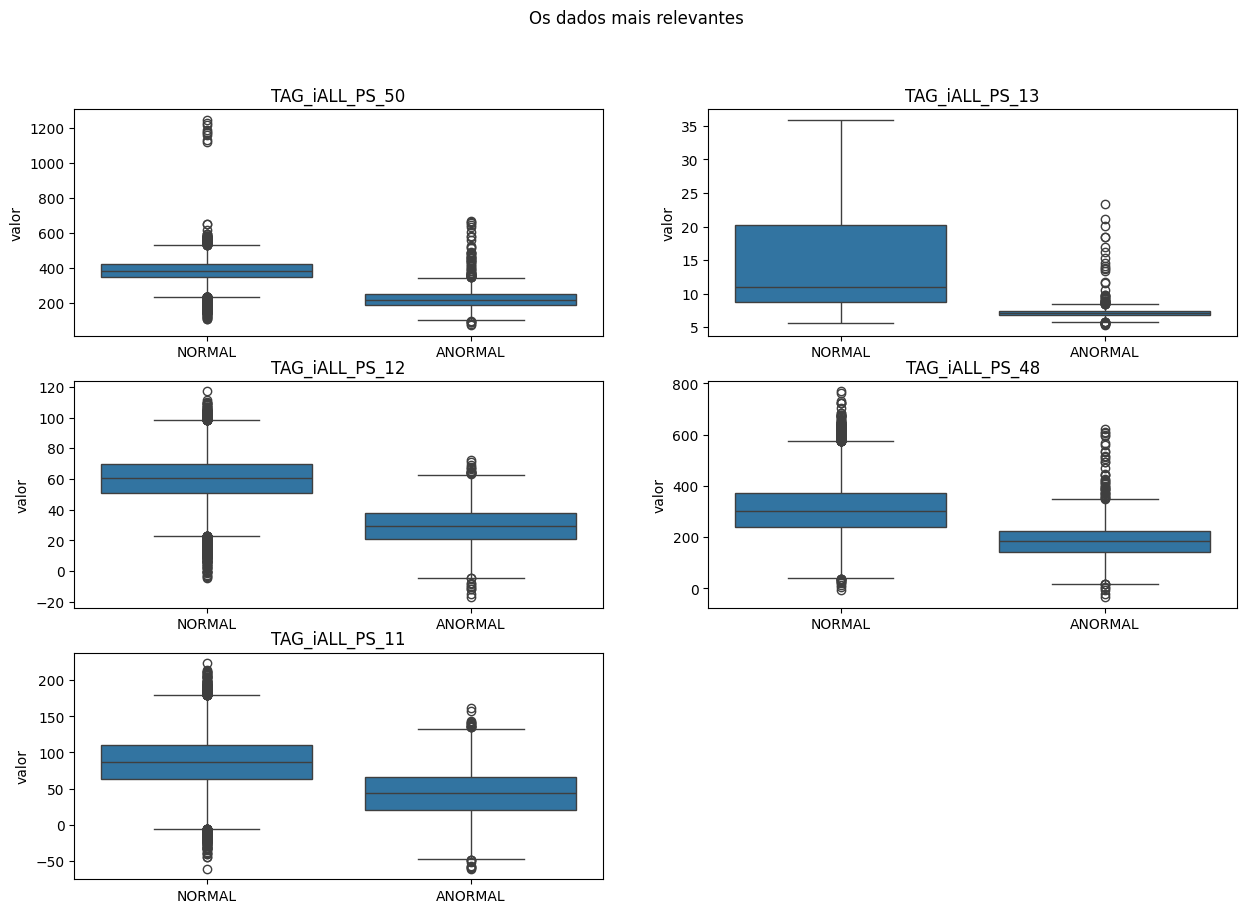

In [162]:
figura, axes = plt.subplots(3,2, figsize=(15,10)) 
figura.suptitle("Os dados mais relevantes", fontsize=12) 

axes_flat = axes.flatten()

for i, coluna in enumerate(tag_mais_relevantes):
    sns.boxplot(data=dado_frame, x='target_iALL_PS', y=coluna, ax=axes_flat[i])
    axes_flat[i].set_title(coluna)
    axes_flat[i].set_xlabel('')
    axes_flat[i].set_ylabel('valor')

axes_flat[5].remove()

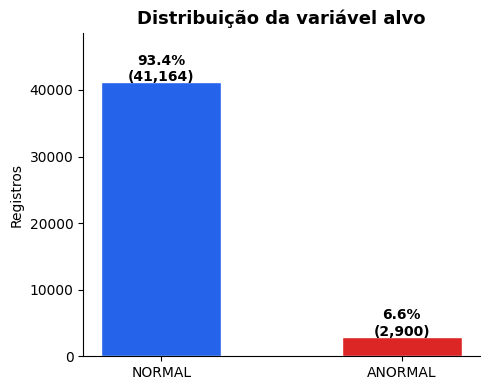

In [163]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(5, 4))
counts = dado_frame['target_iALL_PS'].value_counts()
cores = ['#2563EB', '#DC2626']
bars = ax.bar(counts.index, counts.values, color=cores, width=0.5, edgecolor='white')

for bar, val in zip(bars, counts.values):
    pct = val / counts.sum() * 100
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
            f'{pct:.1f}%\n({val:,})', ha='center', fontsize=10, fontweight='bold')

ax.set_title('Distribuição da variável alvo', fontsize=13, fontweight='bold')
ax.set_ylabel('Registros')
ax.set_ylim(0, counts.max() * 1.18)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('grafico_desbalanceamento.png', dpi=130, bbox_inches='tight')
plt.show()

/tmp/ipykernel_5387/3402780464.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=dado_frame, x='target_iALL_PS', y=col, ax=axes[i],
/tmp/ipykernel_5387/3402780464.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=dado_frame, x='target_iALL_PS', y=col, ax=axes[i],
/tmp/ipykernel_5387/3402780464.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=dado_frame, x='target_iALL_PS', y=col, ax=axes[i],
/tmp/ipykernel_5387/3402780464.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be remo

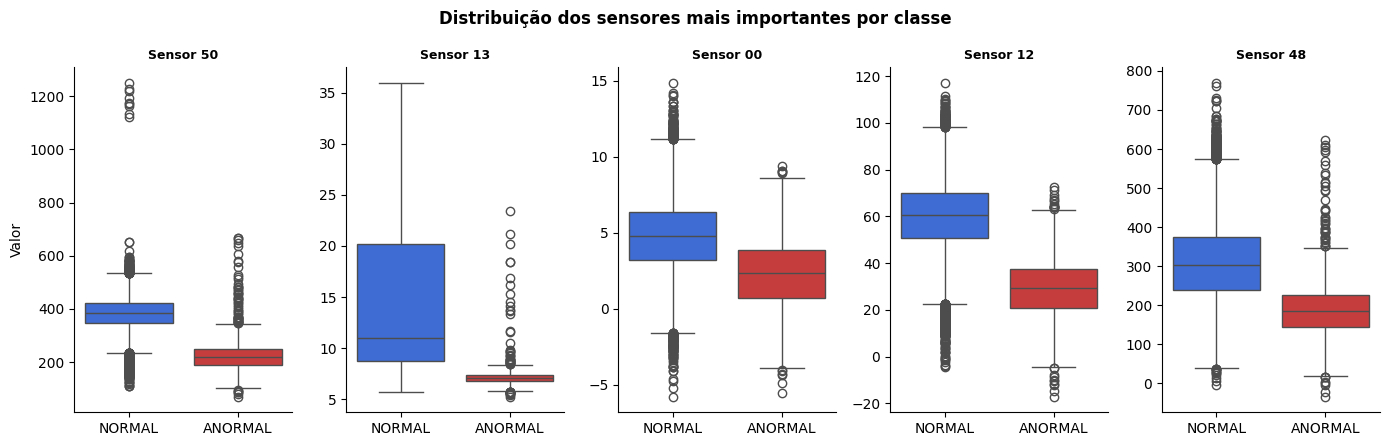

In [164]:
import seaborn as sns

top5 = list(features_importantes_10.head(5).index)

fig, axes = plt.subplots(1, 5, figsize=(14, 4.5))
fig.suptitle('Distribuição dos sensores mais importantes por classe',
             fontsize=12, fontweight='bold')

for i, col in enumerate(top5):
    sns.boxplot(data=dado_frame, x='target_iALL_PS', y=col, ax=axes[i],
                palette={'NORMAL': '#2563EB', 'ANORMAL': '#DC2626'})
    axes[i].set_title(col.replace('TAG_iALL_PS_', 'Sensor '), fontsize=9, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Valor' if i == 0 else '')
    axes[i].spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('grafico_boxplot.png', dpi=130, bbox_inches='tight')
plt.show()